In [1]:
import pandas as pd 
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import plotly.graph_objects as go

In [2]:
data_path = os.path.join('..','data', 'raw', 'dados_completos.csv')
df = pd.read_csv(data_path)
df

,data,4393,21084,24369,27640,4390,24364
0,2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
1,2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2,2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
3,2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
4,2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...,...
168,2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078
169,2026-04-01,121.06,5.51,5.8,2.37,1.09,110.95732
170,2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587
171,2026-06-01,124.07,NaN,NaN,NaN,1.12,NaN


4393	Índice de Confiança do Consumidor 

21084	Inadimplência da carteira de crédito - Pessoas físicas - Total 

24369	Taxa de desocupação - PNADC 

27640 - 27640	Taxa média mensal de juros das operações de crédito não rotativo - Pessoas físicas - Total 

4390 - selic 


24364	Índice de Atividade Econômica do Banco Central (IBC-Br) - com ajuste sazonal



In [3]:
df = df.rename(columns={'4393': 'Confiança_consumidor', 
                        '21084':'Inadimplencia_PF', 
                        '24369':'Desemprego',
                        '27640':'Juros_nao_rotativos_PF',
                        '4390':'SELIC', 
                        '24364':'IBC-Br'})
df

,data,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
0,2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
1,2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2,2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
3,2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
4,2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...,...
168,2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078
169,2026-04-01,121.06,5.51,5.8,2.37,1.09,110.95732
170,2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587
171,2026-06-01,124.07,NaN,NaN,NaN,1.12,NaN


In [4]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data                    173 non-null    datetime64[us]
 1   Confiança_consumidor    173 non-null    float64       
 2   Inadimplencia_PF        171 non-null    float64       
 3   Desemprego              171 non-null    float64       
 4   Juros_nao_rotativos_PF  171 non-null    float64       
 5   SELIC                   173 non-null    float64       
 6   IBC-Br                  171 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 9.6 KB


In [5]:
df = df.set_index('data')
df

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
data,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...
2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078
2026-04-01,121.06,5.51,5.8,2.37,1.09,110.95732
2026-05-01,120.55,5.62,5.6,2.34,1.07,111.03587


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Confiança_consumidor,173.0,118.075665,17.985873,84.55000,106.860000,114.23000,127.05000,165.85000
Inadimplencia_PF,171.0,4.007135,0.639783,2.89000,3.615000,3.93000,4.24500,5.62000
Desemprego,171.0,9.619883,2.824902,5.10000,7.100000,8.80000,12.10000,14.90000
Juros_nao_rotativos_PF,171.0,1.866550,0.206561,1.43000,1.720000,1.84000,2.01000,2.37000
SELIC,173.0,0.778671,0.298048,0.13000,0.540000,0.82000,1.04000,1.28000
IBC-Br,171.0,99.803206,5.169938,83.03874,96.224275,99.51646,102.85532,111.03587


In [7]:
df.isnull().sum()

Confiança_consumidor      0
Inadimplencia_PF          2
Desemprego                2
Juros_nao_rotativos_PF    2
SELIC                     0
IBC-Br                    2
dtype: int64

In [8]:
df = df.dropna()
df

,Confiança_consumidor,Inadimplencia_PF,Desemprego,Juros_nao_rotativos_PF,SELIC,IBC-Br
data,,,,,,
2012-03-01,164.42,5.36,8.0,1.95,0.82,98.06309
2012-04-01,164.99,5.41,7.8,1.88,0.71,98.38205
2012-05-01,163.05,5.51,7.7,1.78,0.74,99.62478
2012-06-01,162.35,5.43,7.6,1.70,0.64,100.33945
2012-07-01,160.56,5.42,7.5,1.72,0.68,100.51105
...,...,...,...,...,...,...
2026-01-01,127.39,5.38,5.4,2.33,1.16,110.05486
2026-02-01,127.39,5.56,5.8,2.30,1.00,110.65892
2026-03-01,125.87,5.40,6.1,2.33,1.21,110.51078


C:\Users\souza\AppData\Local\Temp\ipykernel_22556\3330039567.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


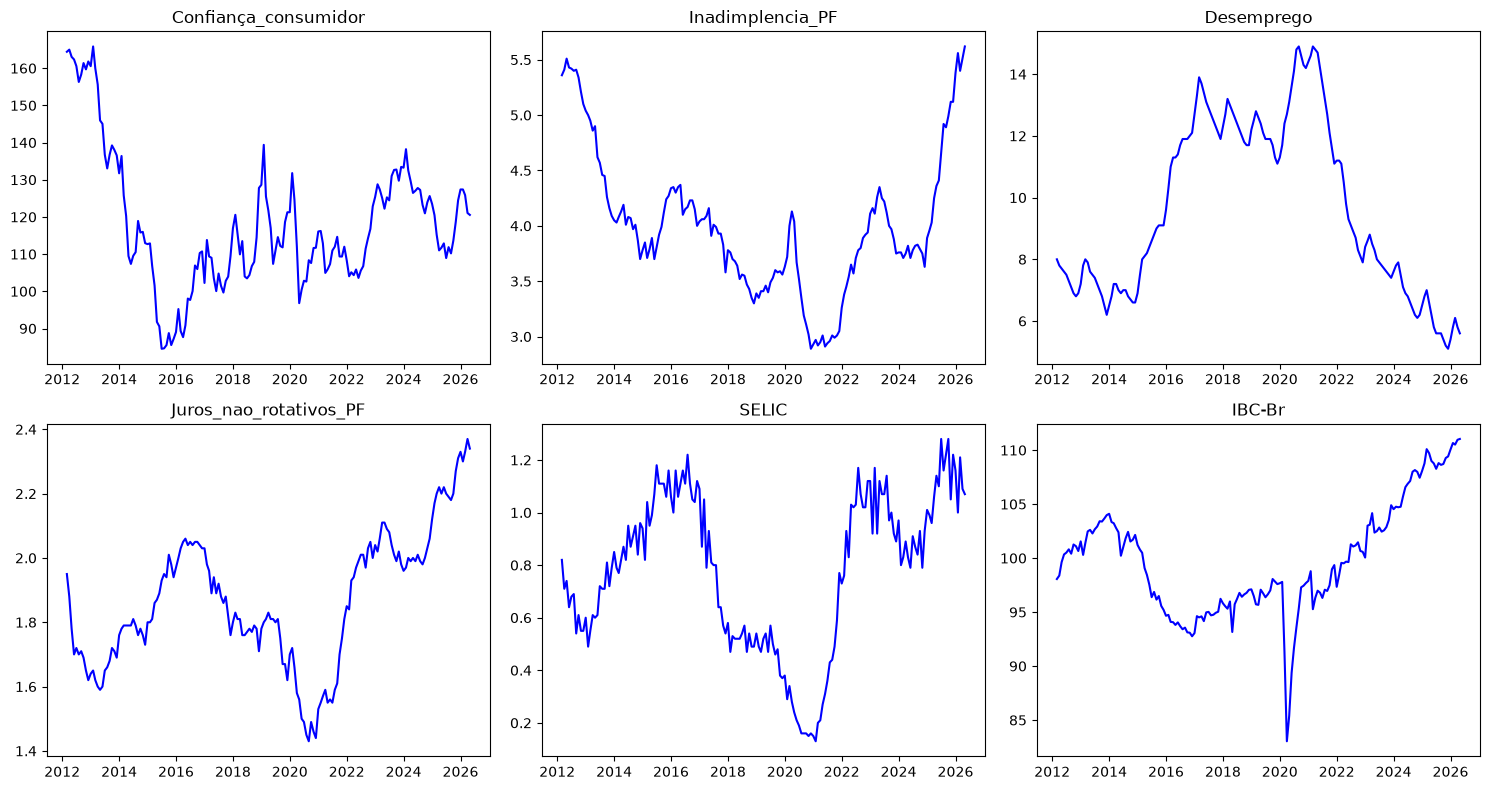

In [9]:
# plotando series agrupadas
fig, ax = plt.subplots(2, 3, figsize=(15,8))
for num, axes in zip(df.columns, ax.ravel()):
    axes.plot(df[num], color='blue')
    axes.set_title(f'{num}')
    fig.tight_layout()
    fig.show()


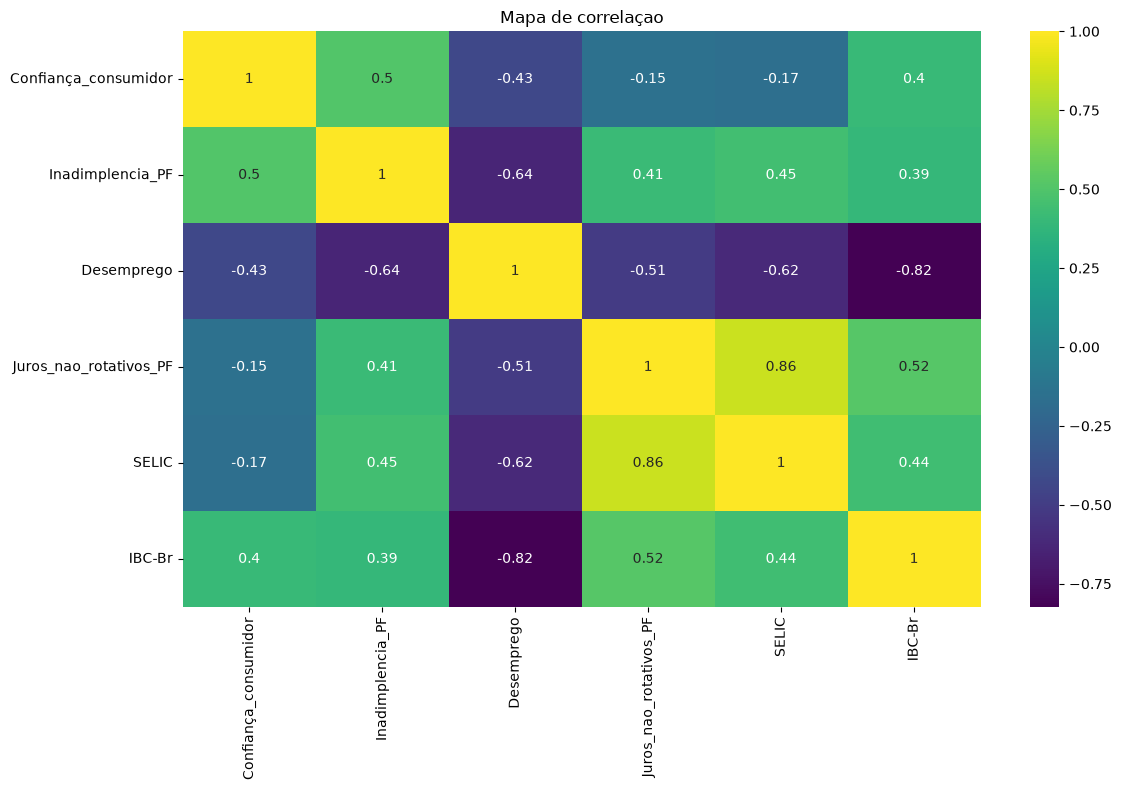

In [10]:
# calculando e plotando correlaçoes
corr = df.corr()
plt.figure(figsize=(12,8))
plt.title('Mapa de correlaçao')
sns.heatmap(corr, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()


In [11]:
df.columns

Index(['Confiança_consumidor', 'Inadimplencia_PF', 'Desemprego',
       'Juros_nao_rotativos_PF', 'SELIC', 'IBC-Br'],
      dtype='str')

C:\Users\souza\AppData\Local\Temp\ipykernel_22556\2955805936.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


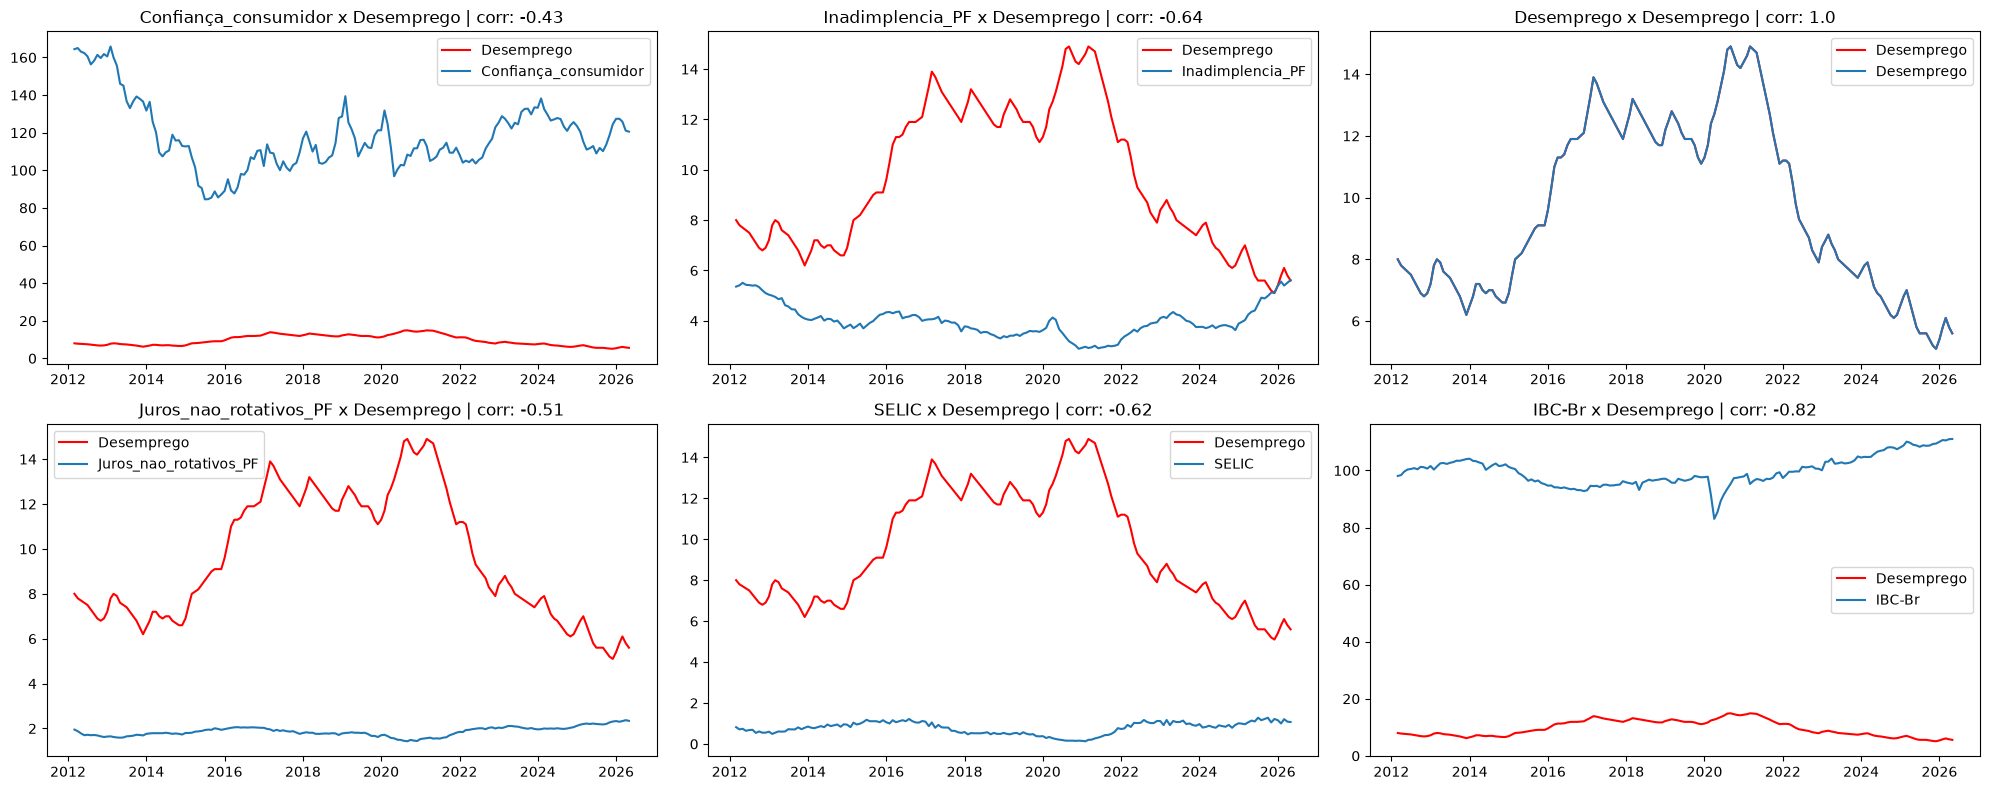

In [12]:
# relacionando taxas com o desemprego 
desemprego = df['Desemprego']
corr_desemprego = df.corr()['Desemprego']
fig, ax = plt.subplots(2, 3, figsize=(20,8))
for i, axes, corr in zip(df.columns, ax.ravel(), corr_desemprego):
    axes.plot(desemprego, color='red', label='Desemprego')
    axes.plot(df[i],label=f'{i}')
    axes.set_title(f'{i} x Desemprego | corr: {round(corr, 2)}')
    fig.tight_layout()
    axes.legend()
    fig.show()

In [14]:
df.columns

Index(['Confiança_consumidor', 'Inadimplencia_PF', 'Desemprego',
       'Juros_nao_rotativos_PF', 'SELIC', 'IBC-Br'],
      dtype='str')